In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("owid-co2-data.csv")


print(f"Size of data: {df.shape}")


Size of data: (50411, 79)


In [3]:
df.head(n=3)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560,,0.0,0.0,,,,...,,,,,,,,,,
1,Afghanistan,1751,AFG,,,0.0,,,,,...,,,,,,,,,,
2,Afghanistan,1752,AFG,,,0.0,,,,,...,,,,,,,,,,


In [4]:
colums = df.columns 

# We first inspect if the column names are formatted with no extra spacings around it
try:
    # should print 1751
    print(df.at[1, 'year'])
except KeyError:
    print("No column name found!")
    


No column name found!


In [5]:
# we see that the cells have extra spaces, making data processing difficult
# therefore we have to rename the columns
for col in colums:
    c = col.strip()
    df.rename(columns={col: c}, inplace=True)
    
columns = df.columns
print("Renamed columns!")

try:
    # should print 1751
    print(df.at[1, 'year'])
except KeyError:
    print("No column name found!")

                                                   

Renamed columns!
1751


In [6]:
# check the same with the cell values
# from inspection we see that blank spaces are filled with spaces rather than an empty string

def is_empty(a_str):
    if type(a_str) == str: 
        if a_str.strip() == '':
            return 1
    else:
        return 0 

empty_strings_count = 0

for col in columns:
    empty_strings_count += (df[col].apply(lambda x: is_empty(x))).sum()

print(f"Missing value count: {empty_strings_count}")


Missing value count: 2105184.0


In [7]:

countries = df['country'].unique()
for country in countries[:3]:
    print(f"|{country}|")
    
# there are unnecessary spaces 
# so replace with nan


df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
df = df.replace(r'^\s*$', np.nan, regex=True)

print("\nRemoved spaces\n")
countries = df['country'].unique()
for country in countries[:3]:
    print(f"|{country}|")

|Afghanistan                             |
|Africa                                  |
|Africa (GCP)                            |

Removed spaces

|Afghanistan                             |
|Africa                                  |
|Africa (GCP)                            |


In [8]:
# due to the amount of missing values and considering this is historical data that does not make sense to fill with statistic like mean, 
# dropping the rows that are missing >90% of the values makes the most sense 
empty_strings_count = 0
df = df.drop(df[df.isna().mean(axis=1) > 0.90].index)




In [15]:
# Partner B (Boyu): EDA
import matplotlib.pyplot as plt

# small table for plotting; focus countries already exclude World/region rows
work = df[["country", "year", "co2", "co2_per_capita", "gdp"]].copy()
work["country"] = work["country"].astype(str).str.strip()
work["year"] = pd.to_numeric(work["year"], errors="coerce")
work["co2"] = pd.to_numeric(work["co2"], errors="coerce")
work["co2_per_capita"] = pd.to_numeric(work["co2_per_capita"], errors="coerce")
work["gdp"] = pd.to_numeric(work["gdp"], errors="coerce")

focus = ["United States", "Japan", "Germany", "South Korea", "United Kingdom"]
eda = work[(work["country"].isin(focus)) & (work["year"] >= 1990)].copy()

print(eda.dtypes)
print(eda.shape)
print(eda["country"].value_counts())
eda.head()


country               str
year                int64
co2               float64
co2_per_capita    float64
gdp               float64
dtype: object
(175, 5)
country
Germany           35
Japan             35
South Korea       35
United Kingdom    35
United States     35
Name: count, dtype: int64


,country,year,co2,co2_per_capita,gdp
18285,Germany,1990,1054.795898,13.233256,2.015547e+12
18286,Germany,1991,1016.929504,12.663626,2.141316e+12
18287,Germany,1992,969.464417,11.978324,2.204952e+12
18288,Germany,1993,959.385864,11.773517,2.206291e+12
18289,Germany,1994,943.227661,11.534621,2.283953e+12


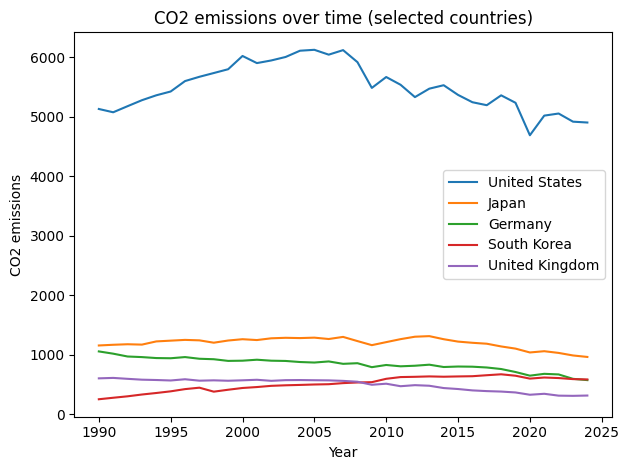

In [16]:
# Plot 1: CO2 over time
for country in focus:
    temp = eda[eda["country"] == country]
    plt.plot(temp["year"], temp["co2"], label=country)

plt.xlabel("Year")
plt.ylabel("CO2 emissions")
plt.title("CO2 emissions over time (selected countries)")
plt.legend()
plt.tight_layout()
plt.show()

# Insight: several of these high-income countries look flat or declining
# after the 1990s, rather than rising steadily.

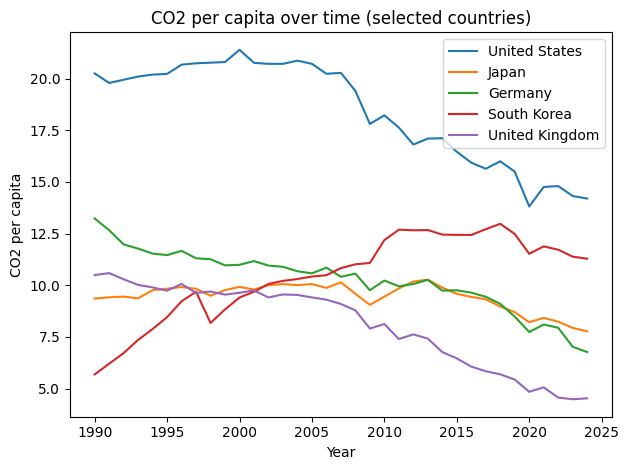

In [17]:
# Plot 2: CO2 per capita over time
for country in focus:
    temp = eda[eda["country"] == country]
    plt.plot(temp["year"], temp["co2_per_capita"], label=country)

plt.xlabel("Year")
plt.ylabel("CO2 per capita")
plt.title("CO2 per capita over time (selected countries)")
plt.legend()
plt.tight_layout()
plt.show()

# Insight: the ranking can differ from total emissions;
# the US stays relatively high per person even when others decline.

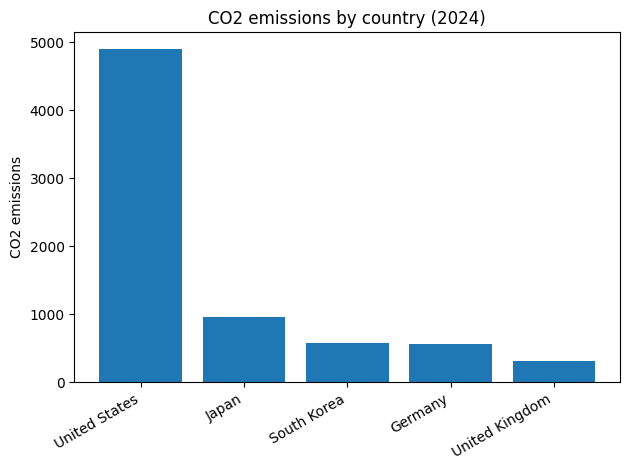

              country  year          co2  co2_per_capita
48007   United States  2024  4904.119629       14.197287
23812           Japan  2024   961.867310        7.772474
43038     South Korea  2024   583.679138       11.285893
18319         Germany  2024   572.319153        6.768824
47782  United Kingdom  2024   312.905548        4.525799


In [18]:
# Plot 3: latest-year CO2 comparison
latest = eda["year"].max()
snap = eda[eda["year"] == latest].sort_values("co2", ascending=False)

plt.bar(snap["country"], snap["co2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("CO2 emissions")
plt.title(f"CO2 emissions by country ({int(latest)})")
plt.tight_layout()
plt.show()

print(snap[["country", "year", "co2", "co2_per_capita"]])